# Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.patches import Patch, Rectangle

# Distribution of similarity scores

In [ ]:
def draw_similarity_distribution(groups:dict, output_path:str="similarity_distribution.png"):
    COLOR_NAME = "#3B5490"
    COLOR_DESC = "#C0C8D8"
    GAP = 0.08
    VIOLIN_WIDTH = 0.38
    BOX_HW = 0.025   # half-width of the full box — keep thin

    def half_violin(ax, values, x_center, side, color, alpha=0.78, bw=0.25):
        kde = stats.gaussian_kde(values, bw_method=bw)
        y = np.linspace(values.min(), values.max(), 300)
        d = kde(y)
        d = d / d.max() * VIOLIN_WIDTH
        edge = x_center - GAP / 2 if side == "left" else x_center + GAP / 2
        if side == "left":
            ax.fill_betweenx(y, edge - d, edge, color=color, alpha=alpha)
        else:
            ax.fill_betweenx(y, edge, edge + d, color=color, alpha=alpha)

    def full_box(ax, values, x_center, side, color="#D4A800"):
        """Full box plot centered on the inner edge of the violin."""
        edge = x_center - GAP / 2 if side == "left" else x_center + GAP / 2
        q1, med, q3 = np.percentile(values, [25, 50, 75])
        iqr = q3 - q1
        lo = max(values.min(), q1 - 1.5 * iqr)
        hi = min(values.max(), q3 + 1.5 * iqr)
        ax.plot([edge, edge], [lo, hi], color=color, lw=1.5, zorder=3)
        ax.add_patch(Rectangle((edge - BOX_HW, q1), 2 * BOX_HW, iqr, color=color, zorder=4))
        ax.plot(edge, med, "o", color="white", ms=5, zorder=5)

    fig, ax = plt.subplots(figsize=(6, 5))

    for i, (label, halves) in enumerate(groups.items()):
        name_vals = halves["Process Name"]
        desc_vals = halves["Analytic Narrative"]

        half_violin(ax, name_vals, i, side="left",  color=COLOR_NAME)
        half_violin(ax, desc_vals, i, side="right", color=COLOR_DESC)
        full_box(ax, name_vals, i, side="left")
        full_box(ax, desc_vals, i, side="right")

    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(list(groups.keys()), fontsize=12)
    ax.set_ylabel("Accuracy (Semantic Similarity)", fontsize=12)
    ax.set_xlabel("Noise Level", fontsize=12)
    ax.set_ylim(0.3, 1.05)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    legend_handles = [
        Patch(facecolor=COLOR_NAME, alpha=0.8, label="Process Name Only"),
        Patch(facecolor=COLOR_DESC, alpha=0.8, label="Analytic Narrative Included"),
    ]
    ax.legend(handles=legend_handles, frameon=False, fontsize=10)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')

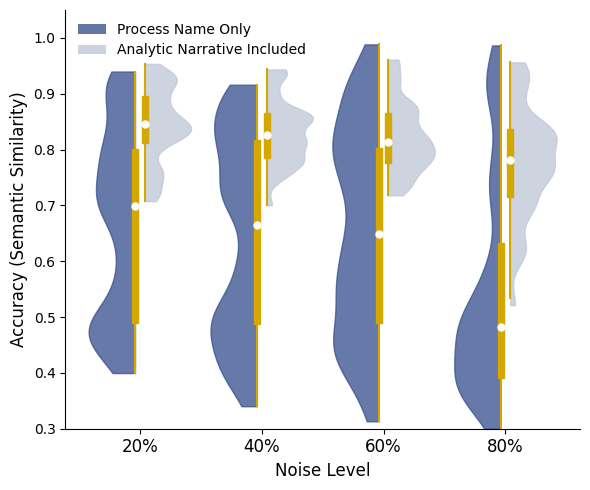

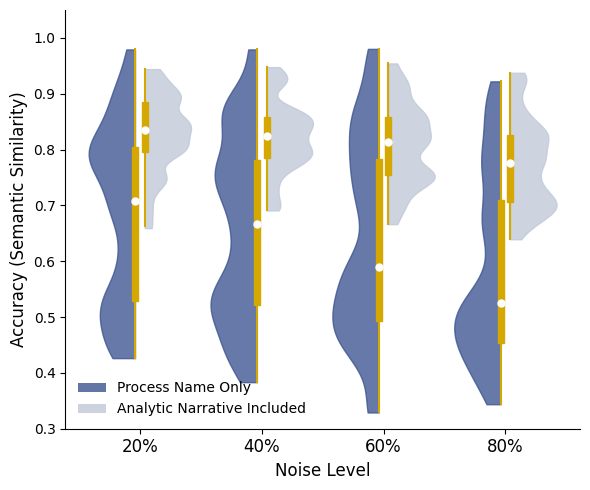

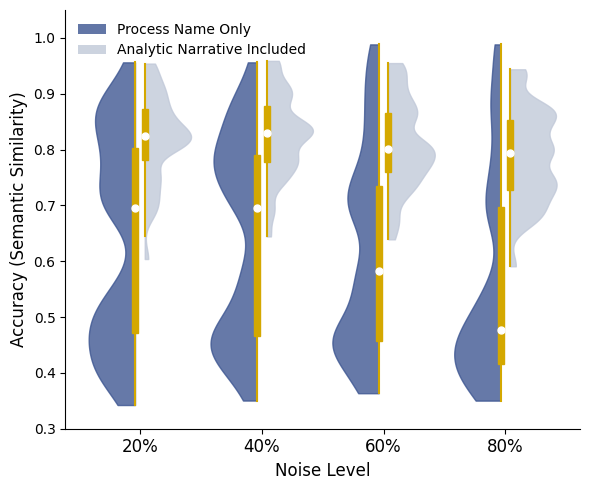

In [ ]:
def load_semantic_similarity_data(base_path:str, noise_levels:list = [20, 40, 60, 80]):
    groups = {}
    for noise in noise_levels:
        groups[f"{noise}%"] = {
            "Process Name": pd.read_csv(f"{base_path}/toy_alzkb_noise_{noise}_combined/evaluation_results_nameOnly.csv")["semantic_similarity"].dropna().values,
            "Analytic Narrative":  pd.read_csv(f"{base_path}/toy_alzkb_noise_{noise}_combined/evaluation_results_descriptionsIncluded.csv")["semantic_similarity"].dropna().values,
        }
    return groups

# ── Draw similarity distribution ────────────────────────────────────────────────
base = "Outputs/gpt-oss:20b"
groups = load_semantic_similarity_data(base)
draw_similarity_distribution(groups, output_path="similarity_distribution_gpt-oss-20b.png")

base = "Outputs/llama3.3:70b/"
groups = load_semantic_similarity_data(base)
draw_similarity_distribution(groups, output_path="similarity_distribution_llama3.3-70b.png")

base = "Outputs/qwen2.5:14b/"
groups = load_semantic_similarity_data(base)
draw_similarity_distribution(groups, output_path="similarity_distribution_qwen2.5-14b.png")


# Sankey: Semantic Similarity → LLM Judge Score

In [29]:
import plotly.graph_objects as go
from IPython.display import display, HTML

SEM_BINS = [
    "Near identical",
    "Strong conceptual similarity",
    "Partial overlap",
    "Low / no semantic relevance",
]

def bin_semantic(score: float) -> str:
    if score >= 0.9:
        return "Near identical"
    elif score >= 0.7:
        return "Strong conceptual similarity"
    elif score >= 0.5:
        return "Partial overlap"
    else:
        return "Low / no semantic relevance"

def _node_y_positions(node_flows: list, lo: float = 0.05, hi: float = 0.95, pad: float = 0.02) -> list:
    """
    Compute top-of-node y positions (Plotly SVG: y=0 top, y=1 bottom).
    Each node's allocated height is proportional to its flow volume.
    """
    n = len(node_flows)
    total = sum(node_flows)
    available = (hi - lo) - pad * (n - 1)

    positions, cursor = [], lo
    for flow in node_flows:
        positions.append(cursor)
        cursor += (flow / total) * available + pad
    return positions

def draw_sankey(csv_path: str, title: str = "Semantic Similarity → LLM Judge Score", output_filename: str = "sankey.png"):
    df = pd.read_csv(csv_path).dropna(subset=["semantic_similarity", "llm_judge_score"])
    df["sem_bin"] = df["semantic_similarity"].apply(bin_semantic)
    df["llm_label"] = df["llm_judge_score"].astype(int).apply(lambda s: f"LLM Score {s}")

    # Ordered: Near identical → Low/no on left; Score 4 → Score 1 on right
    llm_labels = [f"LLM Score {s}" for s in sorted(df["llm_judge_score"].astype(int).unique(), reverse=True)]
    all_labels = SEM_BINS + llm_labels
    idx = {label: i for i, label in enumerate(all_labels)}

    flows = df.groupby(["sem_bin", "llm_label"]).size().reset_index(name="count")
    sources = [idx[r["sem_bin"]]   for _, r in flows.iterrows()]
    targets = [idx[r["llm_label"]] for _, r in flows.iterrows()]
    values  = flows["count"].tolist()

    sem_colors  = ["#2c7bb6", "#74add1", "#fdae61", "#d7191c"]
    llm_colors  = ["#1a9641", "#78c679", "#d9f0a3", "#ffffcc"]  # score 4 → 1
    node_colors = sem_colors + llm_colors[: len(llm_labels)]

    # Flow volume per node (determines node bar height in the Sankey)
    sem_flows = [sum(v for s, v in zip(sources, values) if s == idx[b]) for b in SEM_BINS]
    llm_flows = [sum(v for t, v in zip(targets, values) if t == idx[l]) for l in llm_labels]

    node_x = [0.01] * len(SEM_BINS) + [0.99] * len(llm_labels)
    node_y = _node_y_positions(sem_flows) + _node_y_positions(llm_flows)

    fig = go.Figure(go.Sankey(
        arrangement="snap",
        node=dict(
            pad=20, thickness=22,
            line=dict(color="white", width=0.5),
            label=all_labels,
            color=node_colors,
            # x=node_x,
            # y=node_y,
        ),
        link=dict(source=sources, target=targets, value=values),
    ))
    fig.update_layout(
        title_text=title,
        font=dict(size=13),
        margin=dict(l=120, r=120, t=50, b=20),
    )

    fig.write_html(f"{output_filename}.html")
    fig.write_image(f"{output_filename}.png", scale=3)
    display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False)))


In [31]:
draw_sankey(
    "Outputs/gpt-oss:20b/toy_alzkb_noise_20_combined/evaluation_results_nameOnly.csv",
    title="gpt-oss:20b · noise 20 · Name Only",
    output_filename="sankey_gpt-oss-20b_noise20_nameOnly",
)
draw_sankey(
    "Outputs/gpt-oss:20b/toy_alzkb_noise_20_combined/evaluation_results_descriptionsIncluded.csv",
    title="gpt-oss:20b · noise 20 · Description Included",
    output_filename="sankey_gpt-oss-20b_noise20_descriptionIncluded",
)